# Feature Engineering 02: CRISPR Codependency

This notebook calculates explainable CRISPR codependency features for a small, declared set of candidate gene pairs. It does not calculate every possible gene-by-gene combination, train a model, rank pairs, or create a probability.

Codependency asks whether knocking out two genes produces similar fitness patterns across cell lines. A positive relationship can suggest shared pathway, protein-complex, or biological-process membership. It is not proof of physical binding, direct fusion, or synthetic lethality.

## Biological Question and Feature Contract

For each unordered candidate pair, do the two released post-Chronos CRISPR gene-effect profiles vary together after broad lineage differences are reduced?

The primary biological measurement is `codependency_rho_adjusted`. Coverage, bootstrap uncertainty, leave-one-lineage-out stability, common-essential status, and CRISPR QC are retained as confidence context. They must not silently increase a biological score.

**Grain:** one row per declared canonical unordered candidate pair. The candidate list is explicit and versioned in this notebook.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.stats import spearmanr

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid', context='notebook')
RANDOM_SEED = 25
MIN_LINEAGE_MODELS = 15
MIN_TOTAL_MODELS = 30
BOOTSTRAP_REPLICATES = 500

def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        marker = candidate / 'data' / 'depmap_24Q4' / 'architecture' / 'model_master.csv'
        if marker.exists():
            return candidate
    raise FileNotFoundError('Run this notebook from inside the az-team25 repository.')

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATA = PROJECT_ROOT / 'data' / 'depmap_24Q4'
RAW = DATA / 'raw'
ARCHITECTURE = DATA / 'architecture'
OUTPUT_DIR = ARCHITECTURE / 'feature_engineering'
OUTPUT_DIR.mkdir(exist_ok=True)

PATHS = {
    'model_master': ARCHITECTURE / 'model_master.csv',
    'gene_master': ARCHITECTURE / 'gene_master.csv',
    'crispr_context': ARCHITECTURE / 'model_crispr_context.csv',
    'gene_effect': RAW / 'CRISPRGeneEffect.csv',
    'pair_features': OUTPUT_DIR / 'crispr_codependency_candidate_features.csv',
    'feature_manifest': OUTPUT_DIR / 'crispr_codependency_feature_manifest.json',
}

master = pd.read_csv(PATHS['model_master'], low_memory=False)
genes = pd.read_csv(PATHS['gene_master'], low_memory=False)
crispr_context = pd.read_csv(PATHS['crispr_context'], low_memory=False)
print(f'Model master: {len(master):,} models')
print(f'Genes in identity table: {len(genes):,}')

Model master: 2,105 models
Genes in identity table: 43,839


## 1. Declare the Candidate Pair Panel

The panel deliberately mixes biological hypotheses. Some pairs may show positive codependency and others may not. That is useful: a fusion pair or conditional-dependency pair should not be forced to look like a codependency pair.

In [2]:
candidate_pairs = pd.DataFrame([
    ('BRAF', 'MAP2K1', 'MAPK pathway relationship'),
    ('KRAS', 'RAF1', 'RAS-RAF pathway relationship'),
    ('SMARCA2', 'SMARCA4', 'paralog and SWI/SNF-complex relationship'),
    ('STAG1', 'STAG2', 'paralog and cohesin-complex relationship'),
    ('VPS4A', 'VPS4B', 'paralog relationship'),
    ('ARID1A', 'EZH2', 'directional conditional-dependency example'),
    ('BRCA1', 'PARP1', 'synthetic-lethality context example'),
    ('EML4', 'ALK', 'direct-fusion example'),
    ('BCR', 'ABL1', 'direct-fusion example'),
    ('RPL5', 'RPL11', 'common-essential warning example'),
], columns=['gene_a', 'gene_b', 'selection_reason'])

def canonical_pair(gene_a: str, gene_b: str) -> str:
    return '--'.join(sorted([gene_a.strip().upper(), gene_b.strip().upper()]))

candidate_pairs['pair_id'] = [canonical_pair(a, b) for a, b in zip(candidate_pairs['gene_a'], candidate_pairs['gene_b'])]
assert candidate_pairs['pair_id'].is_unique
display(candidate_pairs)

,gene_a,gene_b,selection_reason,pair_id
0,BRAF,MAP2K1,MAPK pathway relationship,BRAF--MAP2K1
1,KRAS,RAF1,RAS-RAF pathway relationship,KRAS--RAF1
2,SMARCA2,SMARCA4,paralog and SWI/SNF-complex relationship,SMARCA2--SMARCA4
3,STAG1,STAG2,paralog and cohesin-complex relationship,STAG1--STAG2
4,VPS4A,VPS4B,paralog relationship,VPS4A--VPS4B
5,ARID1A,EZH2,directional conditional-dependency example,ARID1A--EZH2
6,BRCA1,PARP1,synthetic-lethality context example,BRCA1--PARP1
7,EML4,ALK,direct-fusion example,ALK--EML4
8,BCR,ABL1,direct-fusion example,ABL1--BCR
9,RPL5,RPL11,common-essential warning example,RPL11--RPL5


## Column Dictionary

| Feature | Simple meaning | Project role |
|---|---|---|
| `codependency_rho_raw` | Spearman correlation before lineage adjustment. | Diagnostic showing the unadjusted relationship. |
| `codependency_rho_adjusted` | Spearman correlation after subtracting each eligible lineage median from both genes. | Primary codependency feature. |
| `shared_models` | Models with both gene-effect measurements in eligible lineages. | Actual correlation denominator. |
| `eligible_lineages` | Lineages with at least 15 pair-measured models. | Prevents tiny lineages being pooled. |
| `bootstrap_ci_low/high` | Resampling interval for adjusted rho. | Shows uncertainty in the feature. |
| `loo_rho_min/max` | Smallest and largest rho after excluding one lineage at a time. | Shows sensitivity to disease context. |
| `loo_sign_consistency` | Fraction of lineage exclusions retaining the baseline direction. | Stability audit, not separate biological evidence. |
| `common_essential_a/b` | Whether either gene is a released common essential. | Warning for broad fitness relationships. |
| `qc_passing_fraction` | Share of contributing models with at least one passing CRISPR screen. | Technical confidence context only. |
| `fdr_bh` | Benjamini-Hochberg adjusted p-value within this declared panel. | Multiple-testing audit, not effect size. |

## 2. Resolve Gene Identity and Load Only Required CRISPR Columns

The full matrix is intentionally not loaded. Gene symbols are resolved through `gene_master`, and only the required post-Chronos columns are read.

In [3]:
requested_symbols = sorted(set(candidate_pairs['gene_a']) | set(candidate_pairs['gene_b']))
gene_lookup = genes.set_index('symbol')
missing_symbols = sorted(set(requested_symbols) - set(gene_lookup.index))
assert not missing_symbols, f'Genes missing from gene_master: {missing_symbols}'

resolved = gene_lookup.loc[requested_symbols, ['crispr_effect_column', 'is_crispr_common_essential']].reset_index()
unmeasured = resolved.loc[resolved['crispr_effect_column'].isna(), 'symbol'].tolist()
assert not unmeasured, f'Genes without released CRISPR effect columns: {unmeasured}'
display(resolved)

header = pd.read_csv(PATHS['gene_effect'], nrows=0).columns.tolist()
model_column = header[0]
selected_effect_columns = resolved['crispr_effect_column'].tolist()
missing_matrix_columns = sorted(set(selected_effect_columns) - set(header))
assert not missing_matrix_columns, f'Resolved columns missing from matrix: {missing_matrix_columns}'

effects = pd.read_csv(PATHS['gene_effect'], usecols=[model_column, *selected_effect_columns], low_memory=False)
effects = effects.rename(columns={model_column: 'model_id'})
column_to_symbol = dict(zip(resolved['crispr_effect_column'], resolved['symbol']))
effects = effects.rename(columns=column_to_symbol)
assert effects['model_id'].is_unique

model_context = master[['model_id', 'oncotree_lineage', 'has_crispr_gene_effect']].merge(
    crispr_context[['model_id', 'any_screen_passes_qc']], on='model_id', how='left', validate='one_to_one'
)
effects = effects.merge(model_context, on='model_id', how='left', validate='one_to_one')
print(f'Loaded {len(effects):,} models and {len(requested_symbols):,} requested gene columns.')

,symbol,crispr_effect_column,is_crispr_common_essential
0,ABL1,ABL1 (25),0
1,ALK,ALK (238),0
2,ARID1A,ARID1A (8289),0
3,BCR,BCR (613),0
4,BRAF,BRAF (673),0
5,BRCA1,BRCA1 (672),0
6,EML4,EML4 (27436),0
7,EZH2,EZH2 (2146),0
8,KRAS,KRAS (3845),0
9,MAP2K1,MAP2K1 (5604),0


Loaded 1,178 models and 20 requested gene columns.


### What this means for the project

The notebook uses the project gene identity table instead of guessing CRISPR columns from gene names. It also reads only the genes required for the declared hypotheses, keeping memory use and accidental feature expansion under control.

## 3. Calculate Lineage-Adjusted Codependency and Stability

For each pair, models missing either gene are excluded. Lineages contribute only when at least 15 measured models remain. We subtract the lineage median independently for each gene, then calculate Spearman correlation on the residual values.

In [4]:
def safe_spearman(x: pd.Series, y: pd.Series) -> tuple[float, float]:
    valid = x.notna() & y.notna()
    if valid.sum() < 3 or x.loc[valid].nunique() < 2 or y.loc[valid].nunique() < 2:
        return np.nan, np.nan
    result = spearmanr(x.loc[valid], y.loc[valid])
    return float(result.statistic), float(result.pvalue)

def bootstrap_rho(frame: pd.DataFrame, replicates: int, seed: int) -> tuple[float, float]:
    rng = np.random.default_rng(seed)
    lineage_groups = [group.index.to_numpy() for _, group in frame.groupby('oncotree_lineage')]
    estimates = []
    for _ in range(replicates):
        sampled_index = np.concatenate([rng.choice(index, size=len(index), replace=True) for index in lineage_groups])
        sampled = frame.loc[sampled_index]
        rho, _ = safe_spearman(sampled['effect_a_adjusted'], sampled['effect_b_adjusted'])
        if pd.notna(rho):
            estimates.append(rho)
    if not estimates:
        return np.nan, np.nan
    return tuple(np.quantile(estimates, [0.025, 0.975]))

def pair_codependency(gene_a: str, gene_b: str, seed: int) -> tuple[dict, pd.DataFrame]:
    pair = effects[['model_id', 'oncotree_lineage', 'any_screen_passes_qc', gene_a, gene_b]].copy()
    pair = pair.rename(columns={gene_a: 'effect_a', gene_b: 'effect_b'})
    pair = pair.dropna(subset=['oncotree_lineage', 'effect_a', 'effect_b'])
    lineage_sizes = pair.groupby('oncotree_lineage')['model_id'].size()
    eligible_lineages = lineage_sizes[lineage_sizes >= MIN_LINEAGE_MODELS].index
    eligible = pair.loc[pair['oncotree_lineage'].isin(eligible_lineages)].copy()

    if len(eligible) < MIN_TOTAL_MODELS or len(eligible_lineages) < 2:
        return {
            'pair_id': canonical_pair(gene_a, gene_b), 'gene_a': gene_a, 'gene_b': gene_b,
            'route_state': 'insufficient_models', 'shared_models': len(eligible),
            'eligible_lineages': len(eligible_lineages),
        }, eligible

    eligible['effect_a_adjusted'] = eligible['effect_a'] - eligible.groupby('oncotree_lineage')['effect_a'].transform('median')
    eligible['effect_b_adjusted'] = eligible['effect_b'] - eligible.groupby('oncotree_lineage')['effect_b'].transform('median')
    rho_raw, p_raw = safe_spearman(eligible['effect_a'], eligible['effect_b'])
    rho_adjusted, p_adjusted = safe_spearman(eligible['effect_a_adjusted'], eligible['effect_b_adjusted'])
    ci_low, ci_high = bootstrap_rho(eligible, BOOTSTRAP_REPLICATES, seed)

    loo_values = []
    for lineage in sorted(eligible['oncotree_lineage'].unique()):
        subset = eligible.loc[eligible['oncotree_lineage'].ne(lineage)]
        rho, _ = safe_spearman(subset['effect_a_adjusted'], subset['effect_b_adjusted'])
        if pd.notna(rho):
            loo_values.append(rho)
    sign_consistency = np.mean(np.sign(loo_values) == np.sign(rho_adjusted)) if loo_values and rho_adjusted != 0 else np.nan

    return {
        'pair_id': canonical_pair(gene_a, gene_b),
        'gene_a': gene_a,
        'gene_b': gene_b,
        'route_family': 'crispr_codependency',
        'route_state': 'measured',
        'codependency_rho_raw': rho_raw,
        'raw_p_value': p_raw,
        'codependency_rho_adjusted': rho_adjusted,
        'adjusted_p_value': p_adjusted,
        'shared_models': len(eligible),
        'eligible_lineages': len(eligible_lineages),
        'bootstrap_ci_low': ci_low,
        'bootstrap_ci_high': ci_high,
        'bootstrap_ci_width': ci_high - ci_low,
        'loo_rho_min': min(loo_values) if loo_values else np.nan,
        'loo_rho_max': max(loo_values) if loo_values else np.nan,
        'loo_sign_consistency': sign_consistency,
        'qc_measured_models': int(eligible['any_screen_passes_qc'].notna().sum()),
        'qc_passing_fraction': eligible['any_screen_passes_qc'].mean(),
    }, eligible

def benjamini_hochberg(values: pd.Series) -> pd.Series:
    result = pd.Series(np.nan, index=values.index, dtype=float)
    valid = values.dropna().sort_values()
    if valid.empty:
        return result
    adjusted = valid * len(valid) / np.arange(1, len(valid) + 1)
    adjusted = adjusted.iloc[::-1].cummin().iloc[::-1].clip(upper=1)
    result.loc[valid.index] = adjusted
    return result

In [5]:
rows = []
pair_model_frames = {}
for pair_index, candidate in candidate_pairs.iterrows():
    row, pair_models = pair_codependency(candidate['gene_a'], candidate['gene_b'], RANDOM_SEED + pair_index)
    row['selection_reason'] = candidate['selection_reason']
    rows.append(row)
    pair_model_frames[candidate['pair_id']] = pair_models

features = pd.DataFrame(rows)
features['fdr_bh'] = benjamini_hochberg(features['adjusted_p_value'])
essential_lookup = gene_lookup['is_crispr_common_essential'].fillna(0).astype(int).to_dict()
features['common_essential_a'] = features['gene_a'].map(essential_lookup).astype('Int64')
features['common_essential_b'] = features['gene_b'].map(essential_lookup).astype('Int64')
features['common_essential_warning'] = features[['common_essential_a', 'common_essential_b']].eq(1).any(axis=1)
features['coverage_fraction_of_crispr_models'] = features['shared_models'] / master['has_crispr_gene_effect'].eq(1).sum()
features['ci_excludes_zero'] = (features['bootstrap_ci_low'] > 0) | (features['bootstrap_ci_high'] < 0)
features['stability_review'] = np.select(
    [
        features['route_state'].ne('measured'),
        features['loo_sign_consistency'].ge(0.8) & features['ci_excludes_zero'],
        features['loo_sign_consistency'].ge(0.8),
    ],
    ['not_evaluable', 'stable_direction_and_interval', 'stable_direction_uncertain_interval'],
    default='lineage_sensitive_or_uncertain',
)
features['source_release'] = master['release'].dropna().iloc[0]
features = features.sort_values('codependency_rho_adjusted', ascending=False).reset_index(drop=True)
display(features)

,pair_id,gene_a,gene_b,route_family,route_state,codependency_rho_raw,raw_p_value,codependency_rho_adjusted,adjusted_p_value,shared_models,eligible_lineages,bootstrap_ci_low,bootstrap_ci_high,bootstrap_ci_width,loo_rho_min,loo_rho_max,loo_sign_consistency,qc_measured_models,qc_passing_fraction,selection_reason,fdr_bh,common_essential_a,common_essential_b,common_essential_warning,coverage_fraction_of_crispr_models,ci_excludes_zero,stability_review,source_release
0,KRAS--RAF1,KRAS,RAF1,crispr_codependency,measured,0.310721,5.264729e-27,0.299518,4.025135e-25,1143,22,0.245379,0.355177,0.109798,0.263809,0.317016,1.000000,1143,1.0,RAS-RAF pathway relationship,4.025135e-24,0,0,False,0.970289,True,stable_direction_and_interval,DepMap 24Q4 Public
1,VPS4A--VPS4B,VPS4A,VPS4B,crispr_codependency,measured,0.151466,2.676406e-07,0.139438,2.221870e-06,1143,22,0.080641,0.202567,0.121925,0.101742,0.153019,1.000000,1143,1.0,paralog relationship,5.554675e-06,0,0,False,0.970289,True,stable_direction_and_interval,DepMap 24Q4 Public
2,BRAF--MAP2K1,BRAF,MAP2K1,crispr_codependency,measured,0.129257,1.167549e-05,0.124989,2.258485e-05,1143,22,0.060917,0.181500,0.120583,0.048709,0.152868,1.000000,1143,1.0,MAPK pathway relationship,4.516970e-05,0,0,False,0.970289,True,stable_direction_and_interval,DepMap 24Q4 Public
3,ABL1--BCR,BCR,ABL1,crispr_codependency,measured,0.094299,1.414385e-03,0.086601,3.388021e-03,1143,22,0.034377,0.151522,0.117144,0.068492,0.102078,1.000000,1143,1.0,direct-fusion example,5.646701e-03,0,0,False,0.970289,True,stable_direction_and_interval,DepMap 24Q4 Public
4,BRCA1--PARP1,BRCA1,PARP1,crispr_codependency,measured,0.076806,9.385851e-03,0.048120,1.039449e-01,1143,22,-0.015202,0.104152,0.119354,0.032407,0.062418,1.000000,1143,1.0,synthetic-lethality context example,1.422379e-01,0,0,False,0.970289,False,stable_direction_uncertain_interval,DepMap 24Q4 Public
5,STAG1--STAG2,STAG1,STAG2,crispr_codependency,measured,-0.042827,1.479018e-01,0.002920,9.214484e-01,1143,22,-0.054381,0.060282,0.114664,-0.017554,0.019105,0.636364,1143,1.0,paralog and cohesin-complex relationship,9.561356e-01,0,0,False,0.970289,False,lineage_sensitive_or_uncertain,DepMap 24Q4 Public
6,ARID1A--EZH2,ARID1A,EZH2,crispr_codependency,measured,0.054888,6.359222e-02,0.001629,9.561356e-01,1143,22,-0.060377,0.062422,0.122798,-0.014371,0.022559,0.636364,1143,1.0,directional conditional-dependency example,9.561356e-01,0,0,False,0.970289,False,lineage_sensitive_or_uncertain,DepMap 24Q4 Public
7,ALK--EML4,EML4,ALK,crispr_codependency,measured,-0.046461,1.164422e-01,-0.046801,1.137903e-01,1143,22,-0.110444,0.016877,0.127322,-0.056127,-0.032647,1.000000,1143,1.0,direct-fusion example,1.422379e-01,0,0,False,0.970289,False,stable_direction_uncertain_interval,DepMap 24Q4 Public
8,SMARCA2--SMARCA4,SMARCA2,SMARCA4,crispr_codependency,measured,-0.132834,6.607766e-06,-0.151957,2.445888e-07,1143,22,-0.205209,-0.099456,0.105754,-0.163066,-0.119572,1.000000,1143,1.0,paralog and SWI/SNF-complex relationship,8.152959e-07,0,0,False,0.970289,True,stable_direction_and_interval,DepMap 24Q4 Public
9,RPL11--RPL5,RPL5,RPL11,crispr_codependency,measured,-0.193748,3.953237e-11,-0.207789,1.294766e-12,1143,22,-0.259799,-0.151989,0.107810,-0.222447,-0.192627,1.000000,1143,1.0,common-essential warning example,6.473829e-12,1,1,True,0.970289,True,stable_direction_and_interval,DepMap 24Q4 Public


### What this means for the project

A larger positive adjusted rho means the two knockout profiles rise and fall together after broad lineage medians are removed. The confidence interval and lineage-exclusion range tell us whether that relationship is stable. A negative or near-zero value is not a failed gene pair overall; it means this particular codependency route does not provide positive support.

## 4. Mathematical Feature-Quality Audit

The quality audit separates effect magnitude from reliability. It does not create a composite score because weights have not been approved and no independent outcome label exists.

,pair_id,codependency_rho_adjusted,shared_models,eligible_lineages,coverage_fraction_of_crispr_models,bootstrap_ci_low,bootstrap_ci_high,loo_rho_min,loo_rho_max,loo_sign_consistency,fdr_bh,common_essential_warning,qc_passing_fraction,stability_review
0,KRAS--RAF1,0.299518,1143,22,0.970289,0.245379,0.355177,0.263809,0.317016,1.000000,4.025135e-24,False,1.0,stable_direction_and_interval
1,VPS4A--VPS4B,0.139438,1143,22,0.970289,0.080641,0.202567,0.101742,0.153019,1.000000,5.554675e-06,False,1.0,stable_direction_and_interval
2,BRAF--MAP2K1,0.124989,1143,22,0.970289,0.060917,0.181500,0.048709,0.152868,1.000000,4.516970e-05,False,1.0,stable_direction_and_interval
3,ABL1--BCR,0.086601,1143,22,0.970289,0.034377,0.151522,0.068492,0.102078,1.000000,5.646701e-03,False,1.0,stable_direction_and_interval
4,BRCA1--PARP1,0.048120,1143,22,0.970289,-0.015202,0.104152,0.032407,0.062418,1.000000,1.422379e-01,False,1.0,stable_direction_uncertain_interval
5,STAG1--STAG2,0.002920,1143,22,0.970289,-0.054381,0.060282,-0.017554,0.019105,0.636364,9.561356e-01,False,1.0,lineage_sensitive_or_uncertain
6,ARID1A--EZH2,0.001629,1143,22,0.970289,-0.060377,0.062422,-0.014371,0.022559,0.636364,9.561356e-01,False,1.0,lineage_sensitive_or_uncertain
7,ALK--EML4,-0.046801,1143,22,0.970289,-0.110444,0.016877,-0.056127,-0.032647,1.000000,1.422379e-01,False,1.0,stable_direction_uncertain_interval
8,SMARCA2--SMARCA4,-0.151957,1143,22,0.970289,-0.205209,-0.099456,-0.163066,-0.119572,1.000000,8.152959e-07,False,1.0,stable_direction_and_interval
9,RPL11--RPL5,-0.207789,1143,22,0.970289,-0.259799,-0.151989,-0.222447,-0.192627,1.000000,6.473829e-12,True,1.0,stable_direction_and_interval


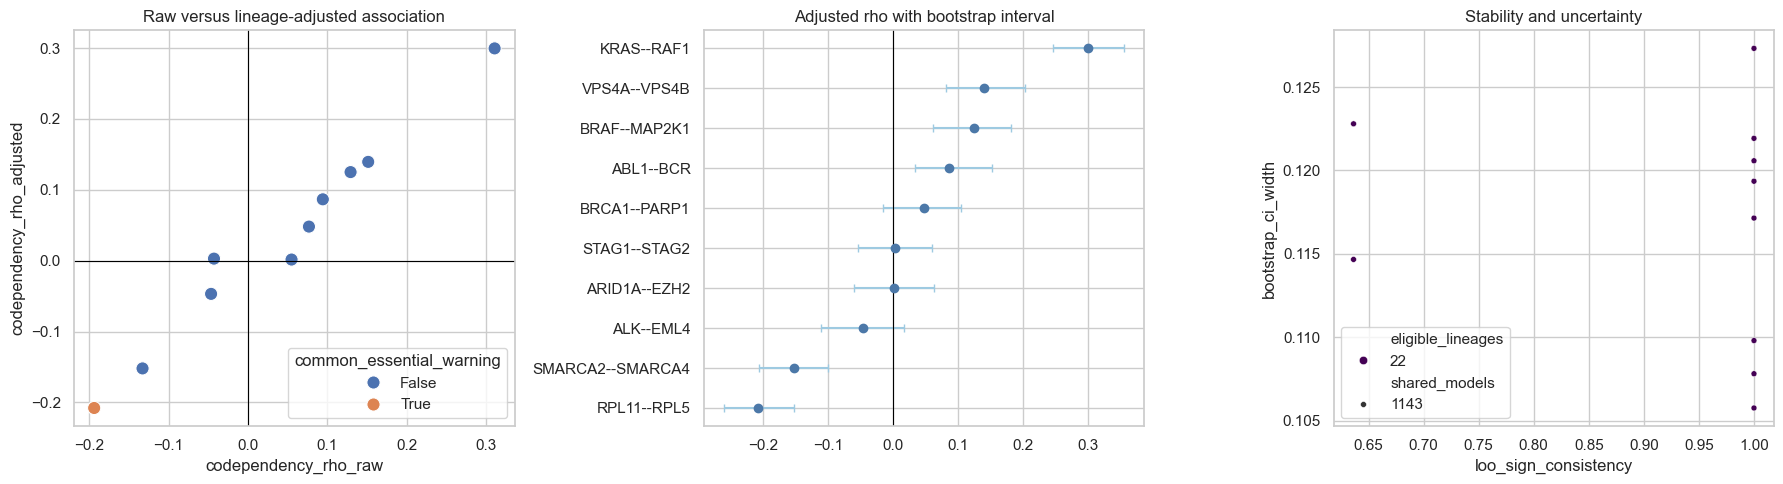

PASS: pair grain, correlation bounds, coverage, QC, and stability values are valid.


In [6]:
assert features['pair_id'].is_unique
assert features.loc[features['route_state'].eq('measured'), 'codependency_rho_adjusted'].between(-1, 1).all()
assert features['coverage_fraction_of_crispr_models'].between(0, 1).all()
assert features['qc_passing_fraction'].dropna().between(0, 1).all()
assert features['loo_sign_consistency'].dropna().between(0, 1).all()

quality_view = features[[
    'pair_id', 'codependency_rho_adjusted', 'shared_models', 'eligible_lineages',
    'coverage_fraction_of_crispr_models', 'bootstrap_ci_low', 'bootstrap_ci_high',
    'loo_rho_min', 'loo_rho_max', 'loo_sign_consistency', 'fdr_bh',
    'common_essential_warning', 'qc_passing_fraction', 'stability_review',
]].copy()
display(quality_view)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(data=features, x='codependency_rho_raw', y='codependency_rho_adjusted', hue='common_essential_warning', s=90, ax=axes[0])
axes[0].axhline(0, color='black', linewidth=0.8); axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Raw versus lineage-adjusted association')

plot_order = features.sort_values('codependency_rho_adjusted').reset_index(drop=True)
axes[1].errorbar(
    plot_order['codependency_rho_adjusted'], np.arange(len(plot_order)),
    xerr=[plot_order['codependency_rho_adjusted'] - plot_order['bootstrap_ci_low'], plot_order['bootstrap_ci_high'] - plot_order['codependency_rho_adjusted']],
    fmt='o', color='#4c78a8', ecolor='#9ecae1', capsize=3,
)
axes[1].set_yticks(np.arange(len(plot_order)), plot_order['pair_id'])
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Adjusted rho with bootstrap interval')

sns.scatterplot(data=features, x='loo_sign_consistency', y='bootstrap_ci_width', size='shared_models', hue='eligible_lineages', palette='viridis', ax=axes[2])
axes[2].set_title('Stability and uncertainty')
plt.tight_layout(); plt.show()

print('PASS: pair grain, correlation bounds, coverage, QC, and stability values are valid.')

### What this means for the project

The effect itself, its uncertainty, and its technical confidence are different concepts. A pair can have a large rho but a wide interval or strong lineage sensitivity. A common-essential warning does not delete the measurement; it tells the dashboard that broad cell-survival biology may contribute.

## 5. Model-Level Example

The strongest adjusted association in the declared panel is plotted to show what the feature represents at model level. This selection is for visual explanation only, not validation.

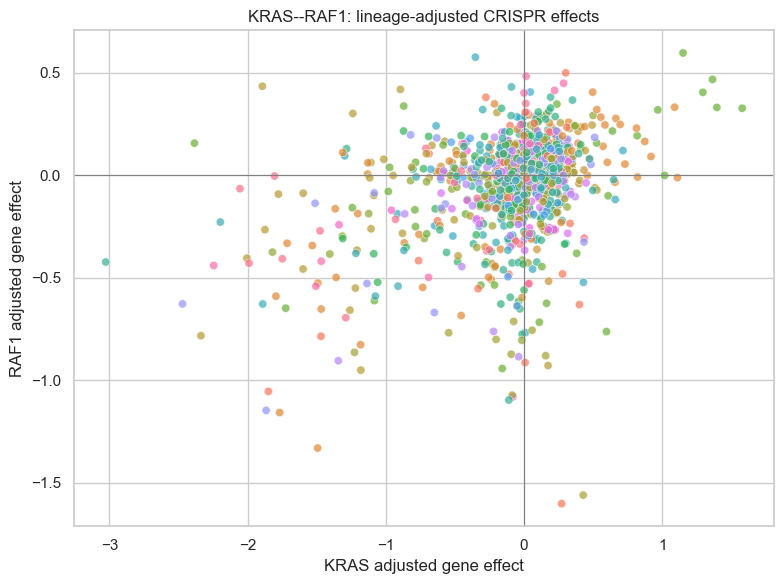

,value
pair_id,KRAS--RAF1
gene_a,KRAS
gene_b,RAF1
route_family,crispr_codependency
route_state,measured
codependency_rho_raw,0.310721
raw_p_value,0.0
codependency_rho_adjusted,0.299518
adjusted_p_value,0.0
shared_models,1143


In [7]:
example_row = features.dropna(subset=['codependency_rho_adjusted']).nlargest(1, 'codependency_rho_adjusted').iloc[0]
example_models = pair_model_frames[example_row['pair_id']]
plt.figure(figsize=(8, 6))
sns.scatterplot(data=example_models, x='effect_a_adjusted', y='effect_b_adjusted', hue='oncotree_lineage', legend=False, alpha=0.7)
plt.axhline(0, color='grey', linewidth=0.8); plt.axvline(0, color='grey', linewidth=0.8)
plt.title(f"{example_row['pair_id']}: lineage-adjusted CRISPR effects")
plt.xlabel(f"{example_row['gene_a']} adjusted gene effect")
plt.ylabel(f"{example_row['gene_b']} adjusted gene effect")
plt.tight_layout(); plt.show()
display(example_row.to_frame('value'))

## 6. Export and Feature Manifest

The exported table contains only the declared candidate panel. The manifest records thresholds, seed, denominator, and exclusions so another contributor can reproduce the feature audit.

In [8]:
features.to_csv(PATHS['pair_features'], index=False)
manifest = {
    'feature_table': str(PATHS['pair_features'].relative_to(PROJECT_ROOT)),
    'grain': 'one row per declared canonical unordered candidate pair',
    'route_family': 'crispr_codependency',
    'source_release': master['release'].dropna().iloc[0],
    'primary_feature': 'codependency_rho_adjusted',
    'input_files': [str(PATHS['model_master'].relative_to(PROJECT_ROOT)), str(PATHS['gene_master'].relative_to(PROJECT_ROOT)), str(PATHS['gene_effect'].relative_to(PROJECT_ROOT)), str(PATHS['crispr_context'].relative_to(PROJECT_ROOT))],
    'candidate_pairs': candidate_pairs.to_dict(orient='records'),
    'minimum_models_per_lineage': MIN_LINEAGE_MODELS,
    'minimum_total_models': MIN_TOTAL_MODELS,
    'bootstrap_replicates': BOOTSTRAP_REPLICATES,
    'random_seed': RANDOM_SEED,
    'lineage_adjustment': 'subtract pair-specific lineage median for each gene before Spearman correlation',
    'missingness_rule': 'models missing either gene effect are excluded; insufficient pairs are not assigned zero',
    'confidence_context_only': ['shared_models', 'eligible_lineages', 'bootstrap interval', 'leave-one-lineage-out stability', 'common-essential flags', 'CRISPR QC'],
    'not_claimed': ['physical interaction', 'direct fusion', 'synthetic lethality', 'probability of success'],
    'row_count': int(len(features)),
}
PATHS['feature_manifest'].write_text(json.dumps(manifest, indent=2), encoding='utf-8')
print(f'Wrote {len(features):,} candidate-pair feature rows to {PATHS["pair_features"]}')
print(f'Wrote manifest to {PATHS["feature_manifest"]}')

Wrote 10 candidate-pair feature rows to data\depmap_24Q4\architecture\feature_engineering\crispr_codependency_candidate_features.csv
Wrote manifest to data\depmap_24Q4\architecture\feature_engineering\crispr_codependency_feature_manifest.json


## Decision Carried Forward

The adjusted rho is the candidate codependency feature. Raw rho is diagnostic. Coverage, QC, common-essential status, bootstrap uncertainty, and lineage-exclusion results are confidence context. A final keep/defer/reject decision requires the later cross-feature audit and, for model inclusion, an independent outcome with lineage-held-out validation.